In [1]:
# ─────────────────────────────────────────────
# CELL 1 — Install & Import
# ─────────────────────────────────────────────
!pip install kagglehub --quiet

import os, shutil, time, json
import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, f1_score, precision_score, recall_score)
from skimage.feature import hog

import tensorflow as tf
from tensorflow.keras import layers, models
import joblib

In [2]:
# ─────────────────────────────────────────────
# CELL 2 — Mount Drive & Download Dataset
# ─────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

import kagglehub
path = kagglehub.dataset_download("olgabelitskaya/flower-color-images")
print("Path dataset:", path)

Mounted at /content/drive


100%|██████████| 50.1M/50.1M [00:00<00:00, 139MB/s]

Extracting files...


Path dataset: /root/.cache/kagglehub/datasets/olgabelitskaya/flower-color-images/versions/7


In [3]:
# ─────────────────────────────────────────────
# CELL 3 — Konfigurasi Path
# ─────────────────────────────────────────────
DATASET_DIR = path
OUTPUT_DIR  = "/content/drive/MyDrive/Tugas 3/output 3"

os.makedirs(OUTPUT_DIR, exist_ok=True)

CLASS_NAMES = ["merah", "orange", "kuning", "biru", "ungu", "pink", "putih"]
IMG_SIZE    = 128

print(f"Dataset : {DATASET_DIR}")
print(f"Output  : {OUTPUT_DIR}")

Dataset : /root/.cache/kagglehub/datasets/olgabelitskaya/flower-color-images/versions/7
Output  : /content/drive/MyDrive/Tugas 3/output 3


In [4]:
# ─────────────────────────────────────────────
# CELL 4 — Fungsi Pelabelan HSV
# ─────────────────────────────────────────────
COLOR_RANGES = {
    "merah":  [(np.array([0,   120,  80]), np.array([8,   255, 255])),
               (np.array([172, 120,  80]), np.array([179, 255, 255]))],
    "orange": [(np.array([9,   120,  80]), np.array([20,  255, 255]))],
    "kuning": [(np.array([21,  100,  80]), np.array([35,  255, 255]))],
    "biru":   [(np.array([90,   60,  50]), np.array([125, 255, 255]))],
    "ungu":   [(np.array([126,  40,  40]), np.array([148, 255, 255]))],
    "pink":   [(np.array([149,  40,  80]), np.array([171, 255, 255]))],
    "putih":  [(np.array([0,     0, 190]), np.array([179,  30, 255]))],
}

def get_flower_mask(img):
    h, w = img.shape[:2]
    mask = np.zeros((h, w), dtype=np.uint8)
    cv2.ellipse(mask, (w//2, h//2), (w//3, h//3), 0, 0, 360, 255, -1)
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    green = cv2.inRange(hsv, np.array([36, 40,  40]), np.array([85,  255, 255]))
    sky   = cv2.inRange(hsv, np.array([90, 30, 150]), np.array([130, 255, 255]))
    exclude = cv2.bitwise_or(green, sky)
    return cv2.bitwise_and(mask, cv2.bitwise_not(exclude))

def label_image(img):
    hsv   = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    fmask = get_flower_mask(img)
    scores = {}
    for name, ranges in COLOR_RANGES.items():
        total = 0
        for lo, hi in ranges:
            m = cv2.inRange(hsv, lo, hi)
            total += cv2.countNonZero(cv2.bitwise_and(m, fmask))
        scores[name] = total
    sorted_s = sorted(scores.items(), key=lambda x: x[1], reverse=True)
    top1_name, top1_val = sorted_s[0]
    top2_val = sorted_s[1][1]
    if top1_val < 300 or (top2_val > 0 and top1_val / top2_val < 1.5):
        return None
    return top1_name

In [5]:
# ─────────────────────────────────────────────
# CELL 5 — Load & Labeling Dataset
# ─────────────────────────────────────────────
images, labels = [], []
skipped = 0

all_files = []
for root, dirs, files_in in os.walk(DATASET_DIR):
    for fname in files_in:
        if fname.lower().endswith((".jpg", ".jpeg", ".png")):
            all_files.append(os.path.join(root, fname))

print(f"Total file ditemukan: {len(all_files)}")

for fpath in all_files:
    img = cv2.imread(fpath)
    if img is None:
        continue
    img   = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    label = label_image(img)
    if label is None:
        skipped += 1
        continue
    images.append(img)
    labels.append(CLASS_NAMES.index(label))

images = np.array(images)
labels = np.array(labels)

print(f"\nTotal terlabel       : {len(images)}")
print(f"Tidak terklasifikasi : {skipped}")
print("\nDistribusi kelas:")
for i, c in enumerate(CLASS_NAMES):
    print(f"  {c:8s}: {np.sum(labels == i)}")

Total file ditemukan: 813

Total terlabel       : 729
Tidak terklasifikasi : 84

Distribusi kelas:
  merah   : 79
  orange  : 57
  kuning  : 136
  biru    : 12
  ungu    : 73
  pink    : 147
  putih   : 225


In [6]:
# ─────────────────────────────────────────────
# CELL 6 — Train/Test Split 80:20
# ─────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    images, labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)
print(f"Train : {len(X_train)}")
print(f"Test  : {len(X_test)}")

Train : 583
Test  : 146


In [7]:
# ─────────────────────────────────────────────
# CELL 7 — Metode Klasik: HOG-ROI + HSV Histogram + SVM
# ─────────────────────────────────────────────
# Alur metode klasik:
# 1. HOG digunakan untuk menonjolkan tepi/bentuk bunga.
# 2. Dari respons HOG dibuat mask/ROI agar area bunga lebih terfokus.
# 3. Warna asli pada ROI tersebut dikembalikan dan dikonversi ke HSV.
# 4. Histogram HSV dari ROI digunakan sebagai fitur untuk klasifikasi SVM.
#
# Catatan metodologis:
# HOG di sini bukan segmentasi bunga sempurna, tetapi seleksi ROI berbasis bentuk/gradien.
# Ini lebih sesuai untuk studi kasus warna dibanding SVM + HOG grayscale murni.


def create_hog_roi_mask(img, min_area_ratio=0.03):
    """Membuat mask ROI bunga berbasis respons HOG/gradien.

    Parameter:
    - img: citra BGR ukuran IMG_SIZE x IMG_SIZE.
    - min_area_ratio: luas minimum ROI terhadap ukuran gambar.

    Output:
    - mask uint8 dengan nilai 0 atau 255.
    """
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray = cv2.GaussianBlur(gray, (3, 3), 0)

    # HOG descriptor + visualisasi respons bentuk/tepi.
    _, hog_image = hog(
        gray,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm="L2-Hys",
        visualize=True,
        feature_vector=True
    )

    # Normalisasi respons HOG agar bisa dijadikan mask.
    hog_norm = cv2.normalize(hog_image, None, 0, 255, cv2.NORM_MINMAX)
    hog_norm = hog_norm.astype(np.uint8)
    hog_norm = cv2.GaussianBlur(hog_norm, (5, 5), 0)

    nonzero = hog_norm[hog_norm > 0]
    if len(nonzero) > 0:
        threshold_value = int(max(np.percentile(nonzero, 65), 20))
    else:
        threshold_value = 20

    _, edge_mask = cv2.threshold(hog_norm, threshold_value, 255, cv2.THRESH_BINARY)

    h, w = edge_mask.shape
    min_area = min_area_ratio * h * w

    # Asumsi dataset: bunga umumnya berada di area tengah gambar.
    # Center prior ini membantu mengurangi background tepi gambar.
    center_mask = np.zeros_like(edge_mask)
    cv2.ellipse(
        center_mask,
        (w // 2, h // 2),
        (int(w * 0.45), int(h * 0.45)),
        0, 0, 360, 255, -1
    )

    mask = cv2.bitwise_and(edge_mask, center_mask)

    # HOG biasanya menghasilkan garis/tepi, jadi mask perlu diperluas dan ditutup.
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
    mask = cv2.dilate(mask, kernel, iterations=2)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=2)

    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    valid_contours = [cnt for cnt in contours if cv2.contourArea(cnt) >= min_area]

    roi_mask = np.zeros_like(mask)
    if valid_contours:
        # Ambil beberapa komponen terbesar karena bunga bisa terdiri dari banyak kelopak.
        valid_contours = sorted(valid_contours, key=cv2.contourArea, reverse=True)[:3]
        cv2.drawContours(roi_mask, valid_contours, -1, 255, thickness=-1)
    else:
        # Fallback agar ekstraksi HSV tetap jalan jika respons HOG terlalu lemah.
        roi_mask = center_mask.copy()

    if np.count_nonzero(roi_mask) < min_area:
        roi_mask = center_mask.copy()

    return roi_mask


def extract_hog_roi_hsv_features(imgs, h_bins=32, s_bins=16, v_bins=16):
    """Ekstraksi fitur HSV dari ROI yang diseleksi menggunakan respons HOG."""
    features = []

    for img in imgs:
        roi_mask = create_hog_roi_mask(img)
        hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

        hist_h = cv2.calcHist([hsv], [0], roi_mask, [h_bins], [0, 180])
        hist_s = cv2.calcHist([hsv], [1], roi_mask, [s_bins], [0, 256])
        hist_v = cv2.calcHist([hsv], [2], roi_mask, [v_bins], [0, 256])

        hist = np.concatenate([
            hist_h.flatten(),
            hist_s.flatten(),
            hist_v.flatten()
        ]).astype(np.float32)

        # Normalisasi L1 agar fitur tidak bergantung pada luas ROI.
        hist = hist / (hist.sum() + 1e-8)
        features.append(hist)

    return np.array(features)


print("Ekstraksi fitur HOG-ROI + HSV — training set...")
X_train_hog_roi_hsv = extract_hog_roi_hsv_features(X_train)

print("Ekstraksi fitur HOG-ROI + HSV — test set...")
X_test_hog_roi_hsv = extract_hog_roi_hsv_features(X_test)

print(f"Dimensi fitur HOG-ROI + HSV : {X_train_hog_roi_hsv.shape[1]}")

svm_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(
        kernel="rbf",
        C=10,
        gamma="scale",
        class_weight="balanced",
        probability=True
    ))
])

print("\nTraining SVM + HOG-ROI + HSV...")
t0 = time.time()
svm_pipeline.fit(X_train_hog_roi_hsv, y_train)
svm_train_time = time.time() - t0
print(f"Selesai. Waktu training : {svm_train_time:.2f} detik")

t0 = time.time()
y_pred_svm = svm_pipeline.predict(X_test_hog_roi_hsv)
svm_infer_time = (time.time() - t0) / len(X_test)
print(f"Waktu inferensi per gambar : {svm_infer_time * 1000:.4f} ms")

Ekstraksi fitur HOG-ROI + HSV — training set...
Ekstraksi fitur HOG-ROI + HSV — test set...
Dimensi fitur HOG-ROI + HSV : 64

Training SVM + HOG-ROI + HSV...
Selesai. Waktu training : 0.13 detik
Waktu inferensi per gambar : 0.0522 ms


In [8]:
# ─────────────────────────────────────────────
# CELL 8 — Metode 2: CNN Sederhana
# ─────────────────────────────────────────────
def build_cnn(num_classes):
    model = models.Sequential([
        layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
        layers.Rescaling(1./255),

        layers.Conv2D(32, (3,3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.Conv2D(64, (3,3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.Conv2D(128, (3,3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.4),
        layers.Dense(num_classes, activation="softmax")
    ])
    return model

X_train_rgb = X_train[..., ::-1].astype(np.float32)
X_test_rgb  = X_test[..., ::-1].astype(np.float32)

cnn_model = build_cnn(len(CLASS_NAMES))
cnn_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
cnn_model.summary()

print("\nTraining CNN...")
t0 = time.time()
history = cnn_model.fit(
    X_train_rgb, y_train,
    validation_split=0.1,
    epochs=30,
    batch_size=32,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            patience=5, restore_best_weights=True, verbose=1)
    ],
    verbose=1
)
cnn_train_time = time.time() - t0
print(f"\nSelesai. Waktu training : {cnn_train_time:.2f} detik")

t0 = time.time()
y_pred_cnn = np.argmax(cnn_model.predict(X_test_rgb, verbose=0), axis=1)
cnn_infer_time = (time.time() - t0) / len(X_test)
print(f"Waktu inferensi per gambar : {cnn_infer_time*1000:.4f} ms")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,559 (435.78 KB)

 Trainable params: 111,111 (434.03 KB)

 Non-trainable params: 448 (1.75 KB)


Training CNN...
Epoch 1/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 33s 2s/step - accuracy: 0.6202 - loss: 1.1316 - val_accuracy: 0.2542 - val_loss: 1.9140
Epoch 2/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 30s 2s/step - accuracy: 0.8015 - loss: 0.6075 - val_accuracy: 0.2881 - val_loss: 1.8720
Epoch 3/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 47s 2s/step - accuracy: 0.8302 - loss: 0.4805 - val_accuracy: 0.1864 - val_loss: 1.8187
Epoch 4/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 35s 2s/step - accuracy: 0.9103 - loss: 0.3056 - val_accuracy: 0.5085 - val_loss: 1.7384
Epoch 5/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 42s 2s/step - accuracy: 0.9103 - loss: 0.2727 - val_accuracy: 0.4407 - val_loss: 1.6680
Epoch 6/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 30s 2s/step - accuracy: 0.8855 - loss: 0.3250 - val_accuracy: 0.6102 - val_loss: 1.4989
Epoch 7/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 29s 2s/step - accuracy: 0.9046 - loss: 0.2879 - val_accuracy: 0.3390 - val_loss: 1.5419
Epoch 8/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 29s 2s/step - accuracy: 0.9294 - loss: 0.2338 - val_accuracy: 0

In [9]:
# ─────────────────────────────────────────────
# CELL 9 — Evaluasi & Tabel Ringkasan
# ─────────────────────────────────────────────
def print_metrics(name, y_true, y_pred, train_time, infer_time):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    rec = recall_score(y_true, y_pred, average="weighted", zero_division=0)
    f1_w = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    f1_macro = f1_score(y_true, y_pred, average="macro", zero_division=0)

    print(f"\n{'=' * 56}")
    print(f"Model              : {name}")
    print(f"Akurasi            : {acc:.4f}")
    print(f"Precision Weighted : {prec:.4f}")
    print(f"Recall Weighted    : {rec:.4f}")
    print(f"F1-Score Weighted  : {f1_w:.4f}")
    print(f"F1-Score Macro     : {f1_macro:.4f}")
    print(f"Waktu Train        : {train_time:.2f}s")
    print(f"Waktu Infer        : {infer_time * 1000:.4f}ms/gambar")
    print(f"\n{classification_report(y_true, y_pred, target_names=CLASS_NAMES, zero_division=0)}")

    return acc, prec, rec, f1_w, f1_macro


acc_svm, prec_svm, rec_svm, f1_svm, f1_macro_svm = print_metrics(
    "SVM + HOG-ROI + HSV", y_test, y_pred_svm, svm_train_time, svm_infer_time
)

acc_cnn, prec_cnn, rec_cnn, f1_cnn, f1_macro_cnn = print_metrics(
    "CNN", y_test, y_pred_cnn, cnn_train_time, cnn_infer_time
)

print("\n" + "=" * 78)
print(f"{'Metrik':<24} {'SVM+HOG-ROI+HSV':>20} {'CNN':>14}")
print("-" * 78)

for label, svm_value, cnn_value in [
    ("Akurasi", acc_svm, acc_cnn),
    ("Precision Weighted", prec_svm, prec_cnn),
    ("Recall Weighted", rec_svm, rec_cnn),
    ("F1-Score Weighted", f1_svm, f1_cnn),
    ("F1-Score Macro", f1_macro_svm, f1_macro_cnn),
    ("Train (s)", svm_train_time, cnn_train_time),
    ("Infer (ms/img)", svm_infer_time * 1000, cnn_infer_time * 1000),
]:
    print(f"{label:<24} {svm_value:>20.4f} {cnn_value:>14.4f}")


Model              : SVM + HOG-ROI + HSV
Akurasi            : 0.9658
Precision Weighted : 0.9682
Recall Weighted    : 0.9658
F1-Score Weighted  : 0.9657
F1-Score Macro     : 0.9643
Waktu Train        : 0.13s
Waktu Infer        : 0.0522ms/gambar

              precision    recall  f1-score   support

       merah       1.00      0.88      0.93        16
      orange       1.00      0.91      0.95        11
      kuning       1.00      0.96      0.98        27
        biru       1.00      1.00      1.00         2
        ungu       0.88      1.00      0.94        15
        pink       0.94      1.00      0.97        30
       putih       0.98      0.98      0.98        45

    accuracy                           0.97       146
   macro avg       0.97      0.96      0.96       146
weighted avg       0.97      0.97      0.97       146


Model              : CNN
Akurasi            : 0.4247
Precision Weighted : 0.5382
Recall Weighted    : 0.4247
F1-Score Weighted  : 0.3809
F1-Score Macro    

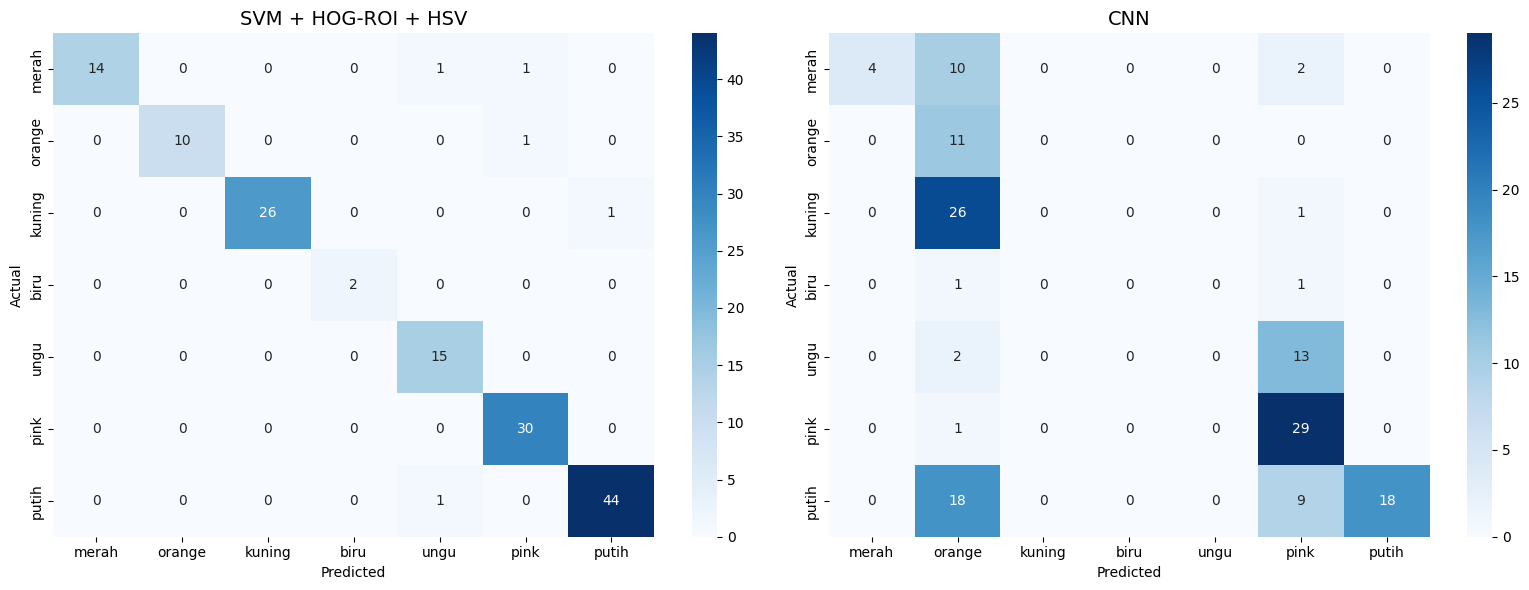

Disimpan: /content/drive/MyDrive/Tugas 3/output 3/confusion_matrix.png


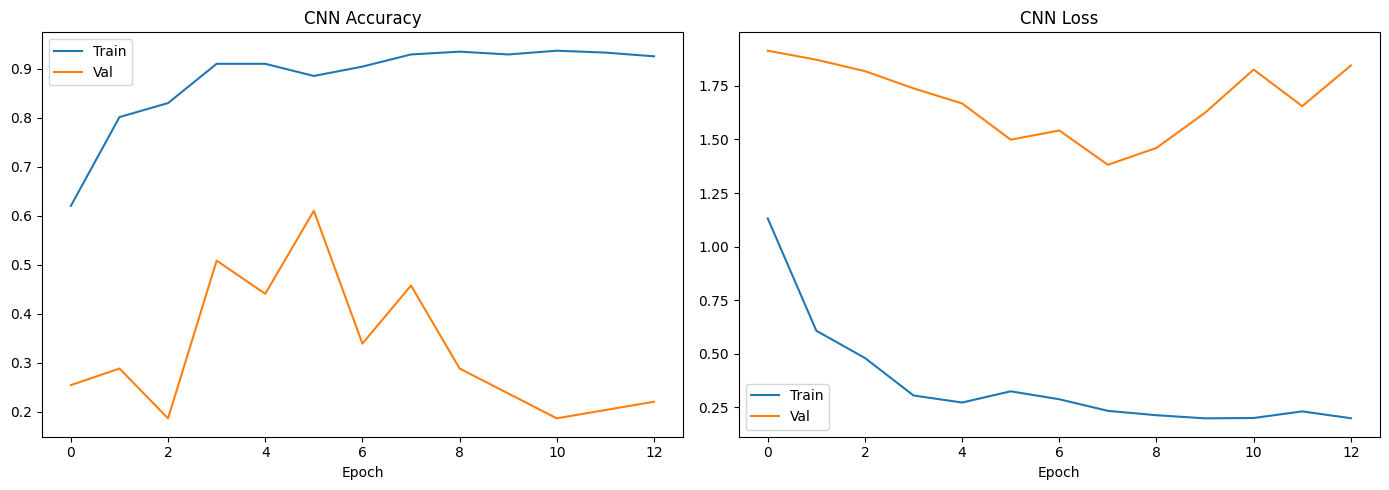

Disimpan: /content/drive/MyDrive/Tugas 3/output 3/cnn_training_history.png


In [10]:
# ─────────────────────────────────────────────
# CELL 10 — Confusion Matrix & Training History
# ─────────────────────────────────────────────
# Confusion matrix untuk pendekatan klasik dan deep learning.
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, y_pred, title in zip(
    axes,
    [y_pred_svm, y_pred_cnn],
    ["SVM + HOG-ROI + HSV", "CNN"]
):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        ax=ax,
        cmap="Blues",
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES
    )
    ax.set_title(title, fontsize=14)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
cm_path = os.path.join(OUTPUT_DIR, "confusion_matrix.png")
plt.savefig(cm_path, dpi=150)
plt.show()
print(f"Disimpan: {cm_path}")

# Training history CNN
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history.history["accuracy"], label="Train")
axes[0].plot(history.history["val_accuracy"], label="Val")
axes[0].set_title("CNN Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history.history["loss"], label="Train")
axes[1].plot(history.history["val_loss"], label="Val")
axes[1].set_title("CNN Loss")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
hist_path = os.path.join(OUTPUT_DIR, "cnn_training_history.png")
plt.savefig(hist_path, dpi=150)
plt.show()
print(f"Disimpan: {hist_path}")

In [11]:
# ─────────────────────────────────────────────
# CELL 11 — Simpan Model & Hasil ke GDrive
# ─────────────────────────────────────────────
# SVM + HOG-ROI + HSV
svm_path = os.path.join(OUTPUT_DIR, "model_svm_hog_roi_hsv.pkl")
joblib.dump(svm_pipeline, svm_path)
print(f"Model SVM + HOG-ROI + HSV disimpan : {svm_path}")

# CNN
cnn_path = os.path.join(OUTPUT_DIR, "model_cnn.keras")
cnn_model.save(cnn_path)
print(f"Model CNN disimpan : {cnn_path}")

# Hasil metrik JSON
results = {
    "SVM_HOG_ROI_HSV": {
        "akurasi": round(acc_svm, 4),
        "precision_weighted": round(prec_svm, 4),
        "recall_weighted": round(rec_svm, 4),
        "f1_score_weighted": round(f1_svm, 4),
        "f1_score_macro": round(f1_macro_svm, 4),
        "waktu_training_s": round(svm_train_time, 2),
        "waktu_inferensi_ms": round(svm_infer_time * 1000, 4)
    },
    "CNN": {
        "akurasi": round(acc_cnn, 4),
        "precision_weighted": round(prec_cnn, 4),
        "recall_weighted": round(rec_cnn, 4),
        "f1_score_weighted": round(f1_cnn, 4),
        "f1_score_macro": round(f1_macro_cnn, 4),
        "waktu_training_s": round(cnn_train_time, 2),
        "waktu_inferensi_ms": round(cnn_infer_time * 1000, 4)
    }
}

json_path = os.path.join(OUTPUT_DIR, "hasil_evaluasi.json")
with open(json_path, "w") as f:
    json.dump(results, f, indent=2)
print(f"Hasil evaluasi disimpan : {json_path}")

Model SVM + HOG-ROI + HSV disimpan : /content/drive/MyDrive/Tugas 3/output 3/model_svm_hog_roi_hsv.pkl
Model CNN disimpan : /content/drive/MyDrive/Tugas 3/output 3/model_cnn.keras
Hasil evaluasi disimpan : /content/drive/MyDrive/Tugas 3/output 3/hasil_evaluasi.json


In [12]:
# ─────────────────────────────────────────────
# CELL 12 — Simpan Hasil Klasifikasi per Gambar (CSV)
# ─────────────────────────────────────────────
import pandas as pd

df_hasil = pd.DataFrame({
    "label_asli": [CLASS_NAMES[i] for i in y_test],
    "prediksi_svm_hog_roi_hsv": [CLASS_NAMES[i] for i in y_pred_svm],
    "prediksi_cnn": [CLASS_NAMES[i] for i in y_pred_cnn],
    "benar_svm_hog_roi_hsv": y_test == y_pred_svm,
    "benar_cnn": y_test == y_pred_cnn,
})

csv_path = os.path.join(OUTPUT_DIR, "hasil_klasifikasi.csv")
df_hasil.to_csv(csv_path, index=False)
print(f"CSV disimpan: {csv_path}")
print(df_hasil.head(10))

CSV disimpan: /content/drive/MyDrive/Tugas 3/output 3/hasil_klasifikasi.csv
  label_asli prediksi_svm_hog_roi_hsv prediksi_cnn  benar_svm_hog_roi_hsv  \
0     kuning                   kuning       orange                   True   
1       pink                     pink         pink                   True   
2     kuning                   kuning       orange                   True   
3       pink                     pink         pink                   True   
4      putih                    putih        putih                   True   
5       ungu                     ungu         pink                   True   
6      putih                    putih        putih                   True   
7      merah                    merah       orange                   True   
8     orange                   orange       orange                   True   
9      putih                    putih       orange                   True   

   benar_cnn  
0      False  
1       True  
2      False  
3       True  
4

In [13]:
# ─────────────────────────────────────────────
# CELL 13 — Sampel Visual Hasil Klasifikasi
# ─────────────────────────────────────────────
def plot_samples(X, y_true, y_pred_svm, y_pred_cnn,
                 class_names, mode="benar", n=16, save_name="sampel.png"):
    """
    mode:
    - 'benar'     → SVM + HOG-ROI + HSV dan CNN benar
    - 'salah'     → minimal ada satu model salah
    - 'svm_salah' → SVM + HOG-ROI + HSV salah, tetapi CNN benar
    - 'cnn_salah' → CNN salah, tetapi SVM + HOG-ROI + HSV benar
    """
    if mode == "benar":
        idx = np.where((y_true == y_pred_svm) & (y_true == y_pred_cnn))[0]
    elif mode == "salah":
        idx = np.where((y_true != y_pred_svm) | (y_true != y_pred_cnn))[0]
    elif mode == "svm_salah":
        idx = np.where((y_true != y_pred_svm) & (y_true == y_pred_cnn))[0]
    elif mode == "cnn_salah":
        idx = np.where((y_true == y_pred_svm) & (y_true != y_pred_cnn))[0]
    else:
        raise ValueError("mode tidak dikenal")

    idx = idx[:n]
    cols = 4
    rows = max(1, int(np.ceil(len(idx) / cols)))

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3.2, rows * 4))
    axes = np.array(axes).reshape(-1)

    for i, ax in enumerate(axes):
        if i >= len(idx):
            ax.axis("off")
            continue

        img_rgb = X[idx[i]][..., ::-1]
        ax.imshow(img_rgb.astype(np.uint8))
        ax.axis("off")

        true_label = class_names[y_true[idx[i]]]
        svm_label = class_names[y_pred_svm[idx[i]]]
        cnn_label = class_names[y_pred_cnn[idx[i]]]

        ax.set_title(
            f"Asli: {true_label}\n"
            f"SVM: {svm_label}\n"
            f"CNN: {cnn_label}",
            fontsize=8,
            color="black"
        )

        all_correct = (true_label == svm_label and true_label == cnn_label)
        all_wrong = (true_label != svm_label and true_label != cnn_label)

        for spine in ax.spines.values():
            if all_correct:
                spine.set_edgecolor("green")
            elif all_wrong:
                spine.set_edgecolor("red")
            else:
                spine.set_edgecolor("orange")
            spine.set_linewidth(2)

    plt.suptitle({
        "benar": "Sampel: SVM + HOG-ROI + HSV dan CNN Benar",
        "salah": "Sampel: Minimal Ada Model yang Salah",
        "svm_salah": "Sampel: SVM + HOG-ROI + HSV Salah, CNN Benar",
        "cnn_salah": "Sampel: CNN Salah, SVM + HOG-ROI + HSV Benar",
    }[mode], fontsize=13, fontweight="bold")

    plt.tight_layout()
    save_path = os.path.join(OUTPUT_DIR, save_name)
    plt.savefig(save_path, dpi=150)
    plt.show()
    print(f"Disimpan: {save_path}")


plot_samples(
    X_test, y_test, y_pred_svm, y_pred_cnn,
    CLASS_NAMES, mode="benar", n=16, save_name="sampel_semua_benar.png"
)

plot_samples(
    X_test, y_test, y_pred_svm, y_pred_cnn,
    CLASS_NAMES, mode="svm_salah", n=16, save_name="sampel_svm_salah_cnn_benar.png"
)

plot_samples(
    X_test, y_test, y_pred_svm, y_pred_cnn,
    CLASS_NAMES, mode="cnn_salah", n=16, save_name="sampel_cnn_salah_svm_benar.png"
)

plot_samples(
    X_test, y_test, y_pred_svm, y_pred_cnn,
    CLASS_NAMES, mode="salah", n=16, save_name="sampel_ada_yang_salah.png"
)

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
!pip install fastapi uvicorn pyngrok nest-asyncio python-multipart

In [ ]:
import nest_asyncio
import uvicorn
import numpy as np
import cv2
import joblib
from fastapi import FastAPI, File, UploadFile
from fastapi.middleware.cors import CORSMiddleware
from fastapi.responses import JSONResponse
from pyngrok import ngrok, conf
import tensorflow as tf
import threading

# ── Ganti dengan token ngrok kamu ──
NGROK_TOKEN = "3EqvPAr8VkWmTTVTf45w6bS0Lqe_722qdqTjFyzbQp7JpmWrL"
conf.get_default().auth_token = NGROK_TOKEN

# ── Path model dari Cell 11 ──
SVM_PATH = "/content/drive/MyDrive/Computer Vision/Tugas 3/output/model_svm_hog_roi_hsv.pkl"
CNN_PATH  = "/content/drive/MyDrive/Computer Vision/Tugas 3/output/model_cnn.keras"

CLASS_NAMES = ["merah", "orange", "kuning", "biru", "ungu", "pink", "putih"]
IMG_SIZE    = 128

# ── Load model ──
print("Loading model SVM...")
svm_pipeline = joblib.load(SVM_PATH)
print("Loading model CNN...")
cnn_model = tf.keras.models.load_model(CNN_PATH)
print("Model siap.")

# ── HOG-ROI + HSV extractor ──
from skimage.feature import hog

def create_hog_roi_mask(img, min_area_ratio=0.03):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray = cv2.GaussianBlur(gray, (3, 3), 0)

    _, hog_image = hog(
        gray,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm="L2-Hys",
        visualize=True,
        feature_vector=True
    )

    hog_norm = cv2.normalize(hog_image, None, 0, 255, cv2.NORM_MINMAX)
    hog_norm = hog_norm.astype(np.uint8)
    hog_norm = cv2.GaussianBlur(hog_norm, (5, 5), 0)

    nonzero = hog_norm[hog_norm > 0]
    threshold_value = int(max(np.percentile(nonzero, 65), 20)) if len(nonzero) > 0 else 20
    _, edge_mask = cv2.threshold(hog_norm, threshold_value, 255, cv2.THRESH_BINARY)

    h, w = edge_mask.shape
    min_area = min_area_ratio * h * w

    center_mask = np.zeros_like(edge_mask)
    cv2.ellipse(center_mask, (w // 2, h // 2), (int(w * 0.45), int(h * 0.45)), 0, 0, 360, 255, -1)

    mask = cv2.bitwise_and(edge_mask, center_mask)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
    mask = cv2.dilate(mask, kernel, iterations=2)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=2)

    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    valid_contours = [cnt for cnt in contours if cv2.contourArea(cnt) >= min_area]

    roi_mask = np.zeros_like(mask)
    if valid_contours:
        valid_contours = sorted(valid_contours, key=cv2.contourArea, reverse=True)[:3]
        cv2.drawContours(roi_mask, valid_contours, -1, 255, thickness=-1)
    else:
        roi_mask = center_mask.copy()

    if np.count_nonzero(roi_mask) < min_area:
        roi_mask = center_mask.copy()

    return roi_mask


def extract_hog_roi_hsv_single(img, h_bins=32, s_bins=16, v_bins=16):
    roi_mask = create_hog_roi_mask(img)
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    hist_h = cv2.calcHist([hsv], [0], roi_mask, [h_bins], [0, 180])
    hist_s = cv2.calcHist([hsv], [1], roi_mask, [s_bins], [0, 256])
    hist_v = cv2.calcHist([hsv], [2], roi_mask, [v_bins], [0, 256])

    hist = np.concatenate([hist_h.flatten(), hist_s.flatten(), hist_v.flatten()]).astype(np.float32)
    hist = hist / (hist.sum() + 1e-8)

    return hist.reshape(1, -1)

# ── FastAPI app ──
app = FastAPI()
app.add_middleware(
    CORSMiddleware,
    allow_origins=["*"],
    allow_methods=["*"],
    allow_headers=["*"],
)

@app.post("/predict")
async def predict(file: UploadFile = File(...)):
    contents = await file.read()
    np_arr   = np.frombuffer(contents, np.uint8)
    img      = cv2.imdecode(np_arr, cv2.IMREAD_COLOR)
    if img is None:
        return JSONResponse({"error": "Gambar tidak valid"}, status_code=400)

    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

    # Prediksi SVM + HOG-ROI + HSV
    svm_feat      = extract_hog_roi_hsv_single(img)
    svm_idx       = svm_pipeline.predict(svm_feat)[0]
    svm_proba     = svm_pipeline.predict_proba(svm_feat)[0]
    svm_label     = CLASS_NAMES[svm_idx]
    svm_confidence = round(float(svm_proba[svm_idx]) * 100, 2)

    # Prediksi CNN
    img_rgb   = img[..., ::-1].astype(np.float32)
    img_input = np.expand_dims(img_rgb, axis=0)
    cnn_proba = cnn_model.predict(img_input, verbose=0)[0]
    cnn_idx   = int(np.argmax(cnn_proba))
    cnn_label = CLASS_NAMES[cnn_idx]
    cnn_confidence = round(float(cnn_proba[cnn_idx]) * 100, 2)

    return {
        "svm_hog_roi_hsv": {"label": svm_label, "confidence": svm_confidence},
        "cnn": {"label": cnn_label, "confidence": cnn_confidence},
    }

# ── Jalankan server ──
nest_asyncio.apply()
public_url = ngrok.connect(8000)
print(f"\nAPI URL: {public_url}")
print("Salin URL di atas, paste ke file HTML nanti.\n")

def run():
    uvicorn.run(app, host="0.0.0.0", port=8000)

thread = threading.Thread(target=run, daemon=True)
thread.start()